In [142]:
import json
import pandas as pd
from tqdm import tqdm
import re
import numpy as np
import matplotlib.pyplot as plt


## Drugs @ FDA

In [24]:
fda_drugs_file = "/shares/animalwelfare.crs.uzh/fda_files/2025_11_11/drug-drugsfda-0001-of-0001.json"

In [16]:

# Load the FDA JSON file
with open(fda_drugs_file, "r") as f:
    data = json.load(f)

# Initialize list for filtered results
orig_records = []

# Loop over results
for result in data.get("results", []):
    submissions = result.get("submissions", [])
    
    # Find the ORIG submission(s)
    orig_subs = [s for s in submissions if s.get("submission_type") == "ORIG"]
    if not orig_subs:
        continue

    orig = orig_subs[0]
    submission_date = orig.get("submission_status_date")
    year = submission_date[:4] if submission_date else None
    # Extract base info
    record = {
        "application_number": result.get("application_number"),
        "sponsor_name": result.get("sponsor_name"),
        "submission_type": orig.get("submission_type"),
        "submission_status_date": submission_date,
        "submission_class_code_description": orig.get("submission_class_code_description"),
        "year": year
    }

    # Extract first product if exists
    products = result.get("products", [])
    if products:
        p = products[0]
        record.update({
            "brand_name": p.get("brand_name"),
            "dosage_form": p.get("dosage_form"),
            "route": p.get("route"),
            "marketing_status": p.get("marketing_status"),
            "active_ingredients": ", ".join(
                f"{a.get('name')}" for a in p.get("active_ingredients", [])
            )
        })

    # If openfda section exists, flatten a few key fields
    openfda = result.get("openfda", {})
    if openfda:
        record.update({
            "openfda_brand_name": ", ".join(openfda.get("brand_name", [])),
            "openfda_generic_name": ", ".join(openfda.get("generic_name", [])),
            "openfda_route": ", ".join(openfda.get("route", [])),
            "openfda_substance_name": ", ".join(openfda.get("substance_name", []))
        })

    orig_records.append(record)

# Convert to DataFrame for easier viewing/analysis
df_orig = pd.DataFrame(orig_records)

In [17]:
# Show summary
print("Found", len(df_orig), "ORIG applications")
df_orig.head()

Found 25712 ORIG applications


,application_number,sponsor_name,submission_type,submission_status_date,submission_class_code_description,year,brand_name,dosage_form,route,marketing_status,active_ingredients,openfda_brand_name,openfda_generic_name,openfda_route,openfda_substance_name
0,ANDA076194,WATSON LABS,ORIG,20020701,None,2002,LISINOPRIL AND HYDROCHLOROTHIAZIDE,TABLET,ORAL,Prescription,"HYDROCHLOROTHIAZIDE, LISINOPRIL",LISINOPRIL AND HYDROCHLOROTHIAZIDE,LISINOPRIL AND HYDROCHLOROTHIAZIDE,ORAL,"HYDROCHLOROTHIAZIDE, LISINOPRIL"
1,ANDA076206,ROCKWELL MEDCL,ORIG,20030917,None,2003,CALCITRIOL,INJECTABLE,INJECTION,Discontinued,CALCITRIOL,NaN,NaN,NaN,NaN
2,ANDA076212,APOTEX,ORIG,20040616,None,2004,CARBIDOPA AND LEVODOPA,"TABLET, EXTENDED RELEASE",ORAL,Discontinued,"CARBIDOPA, LEVODOPA",NaN,NaN,NaN,NaN
3,ANDA076215,FOUGERA PHARMS,ORIG,20031209,None,2003,BETAMETHASONE DIPROPIONATE,"CREAM, AUGMENTED",TOPICAL,Prescription,BETAMETHASONE DIPROPIONATE,NaN,NaN,NaN,NaN
4,ANDA076224,PHARMOBEDIENT,ORIG,20030509,None,2003,FLUTAMIDE,CAPSULE,ORAL,Discontinued,FLUTAMIDE,NaN,NaN,NaN,NaN


In [18]:
df_orig[df_orig['active_ingredients']=="CLADRIBINE"]

,application_number,sponsor_name,submission_type,submission_status_date,submission_class_code_description,year,brand_name,dosage_form,route,marketing_status,active_ingredients,openfda_brand_name,openfda_generic_name,openfda_route,openfda_substance_name
2062,NDA022561,EMD SERONO INC,ORIG,20190329,Type 3 - New Dosage Form,2019,MAVENCLAD,TABLET,ORAL,Prescription,CLADRIBINE,MAVENCLAD,CLADRIBINE,ORAL,CLADRIBINE
8585,ANDA200510,PHARMOBEDIENT,ORIG,20111006,Not Applicable,2011,CLADRIBINE,INJECTABLE,INJECTION,Discontinued,CLADRIBINE,NaN,NaN,NaN,NaN
11798,NDA020229,JANSSEN PHARMS,ORIG,19930226,Type 1 - New Molecular Entity,1993,LEUSTATIN,INJECTABLE,INJECTION,Discontinued,CLADRIBINE,NaN,NaN,NaN,NaN
12849,ANDA075405,HIKMA,ORIG,20000228,None,2000,CLADRIBINE,INJECTABLE,INJECTION,Prescription,CLADRIBINE,CLADRIBINE,CLADRIBINE,INTRAVENOUS,CLADRIBINE
20606,ANDA076571,FRESENIUS KABI USA,ORIG,20040422,None,2004,CLADRIBINE,INJECTABLE,INJECTION,Prescription,CLADRIBINE,CLADRIBINE,CLADRIBINE,INTRAVENOUS,CLADRIBINE
24464,ANDA210856,HISUN PHARM HANGZHOU,ORIG,20191125,None,2019,CLADRIBINE,INJECTABLE,INJECTION,Prescription,CLADRIBINE,CLADRIBINE,CLADRIBINE,INTRAVENOUS,CLADRIBINE


## Label

In [39]:
file_nr = "01"
drug_label_file = f"/shares/animalwelfare.crs.uzh/fda_files/2025_11_11/drug-label-00{file_nr}-of-0013.json"

# Load your drug label JSON (replace filename with yours)
with open(drug_label_file, "r") as f:
    data = json.load(f)

results = data.get("results", [])

records = []

for result in tqdm(results, desc="Processing FDA drug labels", unit="label"):
    openfda = result.get("openfda", {})
    application_numbers = openfda.get("application_number", [])

    # ✅ Skip if no application_number
    if not application_numbers:
        continue

    clinical_text = " ".join(result.get("clinical_studies", []))
    nct_ids = re.findall(r"NCT\s*[-:]?\s*\d{6,8}", clinical_text, flags=re.IGNORECASE)

    # --- Extract only the first sentence from indications_and_usage
    indications_text = " ".join(result.get("indications_and_usage", []))
    match = re.match(r"^(.*?)(?<!\d)\.\s", indications_text)
    first_sentence = match.group(1).strip() if match else indications_text.strip()

    record = {
        "application_number": ", ".join(openfda.get("application_number", [])),
        "label_brand_name": ", ".join(openfda.get("brand_name", [])),
        "label_generic_name": ", ".join(openfda.get("generic_name", [])),
        "label_manufacturer_name": ", ".join(openfda.get("manufacturer_name", [])),
        "label_substance_name": ", ".join(openfda.get("substance_name", [])),
        "indications_first_sent": first_sentence,
        "indications_and_usage": indications_text,
        "clinical_studies": nct_ids,
    }

    records.append(record)

# Convert to DataFrame
df_labels = pd.DataFrame(records)
df_orig = df_orig.merge[df_labels, on="application_numer", how="left")

Processing FDA drug labels: 100%|██████████| 20000/20000 [00:00<00:00, 141800.54label/s]


In [41]:
import json
import re
from pathlib import Path

import pandas as pd
from tqdm import tqdm

# --- only these columns will be written into df_orig
label_cols = [
    "label_brand_name",
    "label_generic_name",
    "label_manufacturer_name",
    "label_substance_name",
    "indications_first_sent",
    "indications_and_usage",
    "clinical_studies",
]

# ensure df_orig has target columns (so .update works cleanly)
for col in label_cols:
    if col not in df_orig.columns:
        df_orig[col] = pd.NA

# regex: first sentence without splitting on numbered list markers like "1."
FIRST_SENTENCE_RE = re.compile(r"^(.*?)(?<!\d)\.\s")

def first_sentence(text: str) -> str:
    if not text:
        return ""
    m = FIRST_SENTENCE_RE.match(text)
    return (m.group(1) if m else text).strip()

# --- iterate files 01..13, process and merge immediately
base_dir = Path("/shares/animalwelfare.crs.uzh/fda_files/2025_11_11")

for i in tqdm(range(1, 14), desc="Processing label files", unit="file"):
    file_nr = f"{i:02d}"
    drug_label_file = base_dir / f"drug-label-00{file_nr}-of-0013.json"

    with open(drug_label_file, "r") as f:
        data = json.load(f)

    results = data.get("results", [])

    # build minimal records for THIS file only
    records = []
    for result in tqdm(results, desc=f"Parsing {drug_label_file.name}", unit="label", leave=False):
        openfda = result.get("openfda", {}) or {}
        application_numbers = openfda.get("application_number", []) or []

        # Skip if no application_number
        if not application_numbers:
            continue

        # clinical trials: tolerant NCT regex (as you wrote)
        clinical_text = " ".join(result.get("clinical_studies", []) or [])
        nct_ids = re.findall(r"NCT\s*[-:]?\s*\d{6,8}", clinical_text, flags=re.IGNORECASE)

        # indications: first sentence only (don’t split on "1.")
        indications_text = " ".join(result.get("indications_and_usage", []) or [])
        match = re.match(r"^(.*?)(?<!\d)\.\s", indications_text)
        first_sent = match.group(1).strip() if match else indications_text.strip()

        # one row per application_number (clean merge key)
        for app_no in application_numbers:
            records.append({
                "application_number": app_no,
                "label_brand_name": ", ".join(openfda.get("brand_name", []) or []),
                "label_generic_name": ", ".join(openfda.get("generic_name", []) or []),
                "label_manufacturer_name": ", ".join(openfda.get("manufacturer_name", []) or []),
                "label_substance_name": ", ".join(openfda.get("substance_name", []) or []),
                "indications_first_sent": first_sent,
                "indications_and_usage": indications_text,
                "clinical_studies": nct_ids,  # keep as list
            })

    # turn this file's records into a df, dedupe by application_number to avoid row explosion
    df_labels_file = pd.DataFrame(records)
    if not df_labels_file.empty:
        df_labels_file = df_labels_file.drop_duplicates(subset=["application_number"], keep="first")
        # in-place update (no _x/_y columns, no row duplication)
        df_orig = df_orig.set_index("application_number")
        df_orig.update(df_labels_file.set_index("application_number")[label_cols])
        df_orig = df_orig.reset_index()

print("✅ Finished merging each label file into df_orig (on the fly).")


Processing label files: 100%|██████████| 13/13 [01:03<00:00,  4.90s/file]                        


✅ Finished merging each label file into df_orig (on the fly).


In [44]:
df_orig

,application_number,sponsor_name,submission_type,submission_status_date,submission_class_code_description,year,brand_name,dosage_form,route,marketing_status,...,openfda_generic_name,openfda_route,openfda_substance_name,label_brand_name,label_generic_name,label_manufacturer_name,label_substance_name,indications_first_sent,indications_and_usage,clinical_studies
0,ANDA076194,WATSON LABS,ORIG,20020701,None,2002,LISINOPRIL AND HYDROCHLOROTHIAZIDE,TABLET,ORAL,Prescription,...,LISINOPRIL AND HYDROCHLOROTHIAZIDE,ORAL,"HYDROCHLOROTHIAZIDE, LISINOPRIL",Lisinopril and Hydrochlorothiazide,LISINOPRIL AND HYDROCHLOROTHIAZIDE,"Actavis Pharma, Inc.","HYDROCHLOROTHIAZIDE, LISINOPRIL",INDICATIONS AND USAGE Lisinopril and Hydrochlo...,INDICATIONS AND USAGE Lisinopril and Hydrochlo...,[]
1,ANDA076206,ROCKWELL MEDCL,ORIG,20030917,None,2003,CALCITRIOL,INJECTABLE,INJECTION,Discontinued,...,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,ANDA076212,APOTEX,ORIG,20040616,None,2004,CARBIDOPA AND LEVODOPA,"TABLET, EXTENDED RELEASE",ORAL,Discontinued,...,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,ANDA076215,FOUGERA PHARMS,ORIG,20031209,None,2003,BETAMETHASONE DIPROPIONATE,"CREAM, AUGMENTED",TOPICAL,Prescription,...,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,ANDA076224,PHARMOBEDIENT,ORIG,20030509,None,2003,FLUTAMIDE,CAPSULE,ORAL,Discontinued,...,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25707,ANDA076154,MYLAN,ORIG,20030820,None,2003,LORATADINE,TABLET,ORAL,Over-the-counter,...,LORATADINE,ORAL,LORATADINE,Loratadine,LORATADINE,Mylan Pharmaceuticals Inc.,LORATADINE,Uses temporarily relieves these symptoms due t...,Uses temporarily relieves these symptoms due t...,[]
25708,ANDA076155,APOTEX INC,ORIG,20030418,None,2003,IPRATROPIUM BROMIDE,"SPRAY, METERED",NASAL,Prescription,...,IPRATROPIUM BROMIDE,NASAL,IPRATROPIUM BROMIDE,Ipratropium Bromide,IPRATROPIUM BROMIDE,Apotex Corp.,IPRATROPIUM BROMIDE,INDICATIONS AND USAGE Ipratropium bromide nasa...,INDICATIONS AND USAGE Ipratropium bromide nasa...,[]
25709,ANDA076162,WATSON LABS TEVA,ORIG,20041014,None,2004,CARBOPLATIN,INJECTABLE,INJECTION,Discontinued,...,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25710,ANDA076163,DR REDDYS,ORIG,20030905,None,2003,AMIODARONE HYDROCHLORIDE,INJECTABLE,INJECTION,Discontinued,...,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [43]:
df_orig[df_orig['active_ingredients']=="CLADRIBINE"]

,application_number,sponsor_name,submission_type,submission_status_date,submission_class_code_description,year,brand_name,dosage_form,route,marketing_status,...,openfda_generic_name,openfda_route,openfda_substance_name,label_brand_name,label_generic_name,label_manufacturer_name,label_substance_name,indications_first_sent,indications_and_usage,clinical_studies
2062,NDA022561,EMD SERONO INC,ORIG,20190329,Type 3 - New Dosage Form,2019,MAVENCLAD,TABLET,ORAL,Prescription,...,CLADRIBINE,ORAL,CLADRIBINE,Mavenclad,CLADRIBINE,"EMD Serono, Inc.",CLADRIBINE,1 INDICATIONS AND USAGE MAVENCLAD is indicated...,1 INDICATIONS AND USAGE MAVENCLAD is indicated...,[NCT00213135]
8585,ANDA200510,PHARMOBEDIENT,ORIG,20111006,Not Applicable,2011,CLADRIBINE,INJECTABLE,INJECTION,Discontinued,...,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
11798,NDA020229,JANSSEN PHARMS,ORIG,19930226,Type 1 - New Molecular Entity,1993,LEUSTATIN,INJECTABLE,INJECTION,Discontinued,...,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
12849,ANDA075405,HIKMA,ORIG,20000228,None,2000,CLADRIBINE,INJECTABLE,INJECTION,Prescription,...,CLADRIBINE,INTRAVENOUS,CLADRIBINE,Cladribine,CLADRIBINE,Hikma Pharmaceuticals USA Inc.,CLADRIBINE,"INDICATIONS AND USAGE Cladribine Injection, US...","INDICATIONS AND USAGE Cladribine Injection, US...",[]
20606,ANDA076571,FRESENIUS KABI USA,ORIG,20040422,None,2004,CLADRIBINE,INJECTABLE,INJECTION,Prescription,...,CLADRIBINE,INTRAVENOUS,CLADRIBINE,Cladribine,CLADRIBINE,"Fresenius Kabi USA, LLC",CLADRIBINE,"INDICATIONS AND USAGE: Cladribine Injection, U...","INDICATIONS AND USAGE: Cladribine Injection, U...",[]
24464,ANDA210856,HISUN PHARM HANGZHOU,ORIG,20191125,None,2019,CLADRIBINE,INJECTABLE,INJECTION,Prescription,...,CLADRIBINE,INTRAVENOUS,CLADRIBINE,Cladribine,CLADRIBINE,"Hisun Pharmaceuticals USA, Inc.",CLADRIBINE,"INDICATIONS FOR USE Cladribine Injection, USP ...","INDICATIONS FOR USE Cladribine Injection, USP ...",[]


In [45]:
df_orig.to_csv("out/FDA_drugs_labels_full.csv",index=False)

## Data Stats

In [143]:
df_orig = pd.read_csv("out/FDA_drugs_labels_full.csv")
df_orig.shape

(25712, 22)

In [144]:
df_orig.columns

Index(['application_number', 'sponsor_name', 'submission_type',
       'submission_status_date', 'submission_class_code_description', 'year',
       'brand_name', 'dosage_form', 'route', 'marketing_status',
       'active_ingredients', 'openfda_brand_name', 'openfda_generic_name',
       'openfda_route', 'openfda_substance_name', 'label_brand_name',
       'label_generic_name', 'label_manufacturer_name', 'label_substance_name',
       'indications_first_sent', 'indications_and_usage', 'clinical_studies'],
      dtype='object')

In [145]:
df_orig.head()

,application_number,sponsor_name,submission_type,submission_status_date,submission_class_code_description,year,brand_name,dosage_form,route,marketing_status,...,openfda_generic_name,openfda_route,openfda_substance_name,label_brand_name,label_generic_name,label_manufacturer_name,label_substance_name,indications_first_sent,indications_and_usage,clinical_studies
0,ANDA076194,WATSON LABS,ORIG,20020701,NaN,2002,LISINOPRIL AND HYDROCHLOROTHIAZIDE,TABLET,ORAL,Prescription,...,LISINOPRIL AND HYDROCHLOROTHIAZIDE,ORAL,"HYDROCHLOROTHIAZIDE, LISINOPRIL",Lisinopril and Hydrochlorothiazide,LISINOPRIL AND HYDROCHLOROTHIAZIDE,"Actavis Pharma, Inc.","HYDROCHLOROTHIAZIDE, LISINOPRIL",INDICATIONS AND USAGE Lisinopril and Hydrochlo...,INDICATIONS AND USAGE Lisinopril and Hydrochlo...,[]
1,ANDA076206,ROCKWELL MEDCL,ORIG,20030917,NaN,2003,CALCITRIOL,INJECTABLE,INJECTION,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ANDA076212,APOTEX,ORIG,20040616,NaN,2004,CARBIDOPA AND LEVODOPA,"TABLET, EXTENDED RELEASE",ORAL,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ANDA076215,FOUGERA PHARMS,ORIG,20031209,NaN,2003,BETAMETHASONE DIPROPIONATE,"CREAM, AUGMENTED",TOPICAL,Prescription,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ANDA076224,PHARMOBEDIENT,ORIG,20030509,NaN,2003,FLUTAMIDE,CAPSULE,ORAL,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [146]:
df_orig[df_orig['submission_class_code_description'].str.contains("Type 3", na=False)][['application_number','submission_class_code_description','indications_first_sent']]


,application_number,submission_class_code_description,indications_first_sent
59,NDA017453,Type 3 - New Dosage Form,INDICATIONS AND USAGE PROGLYCEM is indicated f...
91,NDA017516,Type 3 - New Dosage Form,NaN
136,NDA017603,Type 3 - New Dosage Form,NaN
209,NDA017703,Type 3 - New Dosage Form,NaN
252,NDA017814,Type 3 - New Dosage Form,NaN
...,...,...,...
25600,NDA016936,Type 3 - New Dosage Form,NaN
25605,NDA016954,Type 3 - New Dosage Form,NaN
25698,NDA017352,Type 3 - New Dosage Form,NaN
25699,NDA017354,Type 3 - New Dosage Form,NaN


In [147]:
df_orig[df_orig['active_ingredients'].str.contains("MODAFINIL", na=False)][['active_ingredients', 'year','application_number','submission_class_code_description','indications_first_sent']]


,active_ingredients,year,application_number,submission_class_code_description,indications_first_sent
51,MODAFINIL,2012,ANDA076594,NaN,NaN
156,MODAFINIL,2007,ANDA077892,NaN,NaN
693,ARMODAFINIL,2012,ANDA200156,Not Applicable,NaN
2665,MODAFINIL,2005,ANDA076596,NaN,NaN
5222,MODAFINIL,2004,ANDA076597,NaN,NaN
6242,ARMODAFINIL,2018,ANDA206069,NaN,1 INDICATIONS AND USAGE Armodafinil tablets ar...
7070,MODAFINIL,1998,NDA020717,Type 1 - New Molecular Entity,1 INDICATIONS AND USAGE PROVIGIL is indicated ...
8949,MODAFINIL,2017,ANDA207196,NaN,1 INDICATIONS AND USAGE Modafinil tablets are ...
12328,ARMODAFINIL,2007,NDA021875,Type 5 - New Formulation or New Manufacturer,1 INDICATIONS AND USAGE Armodafinil tablets ar...
13043,MODAFINIL,2014,ANDA077667,NaN,1 INDICATIONS AND USAGE Modafinil tablets are ...


In [148]:
df_orig[df_orig['active_ingredients'].str.contains("MODAFINIL", na=False)][['active_ingredients','year','application_number','submission_class_code_description','indications_first_sent']].to_csv("out/MODAFINIL_example_fda_labels.csv", index=False)

In [181]:
df_all = df_orig.copy()[['application_number', 'submission_class_code_description', 'sponsor_name', 'indications_and_usage', 'year']]

sdesc = df_all["submission_class_code_description"].fillna("")
keep_mask = sdesc.str.match(r"(?i)^\s*type\s*(1)\b")
df_novel = df_all[keep_mask].copy()
df_all['is_novel_drug_therapy'] = keep_mask

repurposed_mask = sdesc.str.match(r"(?i)^\s*type\s*3\b")
df_all['is_repurposed_therapy'] = repurposed_mask

df_all.head()

,application_number,submission_class_code_description,sponsor_name,indications_and_usage,year,is_novel_drug_therapy,is_repurposed_therapy
0,ANDA076194,NaN,WATSON LABS,INDICATIONS AND USAGE Lisinopril and Hydrochlo...,2002,False,False
1,ANDA076206,NaN,ROCKWELL MEDCL,NaN,2003,False,False
2,ANDA076212,NaN,APOTEX,NaN,2004,False,False
3,ANDA076215,NaN,FOUGERA PHARMS,NaN,2003,False,False
4,ANDA076224,NaN,PHARMOBEDIENT,NaN,2003,False,False


In [182]:
df_all.shape

(25712, 7)

In [183]:
df_all.is_novel_drug_therapy.sum(), df_all.is_repurposed_therapy.sum()

(1784, 1669)

In [161]:
df_all[df_all.is_repurposed_therapy]

,application_number,submission_class_code_description,sponsor_name,indications_and_usage,year,is_novel_drug_therapy,is_repurposed_therapy
59,NDA017453,Type 3 - New Dosage Form,TEVA BRANDED PHARM,INDICATIONS AND USAGE PROGLYCEM is indicated f...,1976,False,True
91,NDA017516,Type 3 - New Dosage Form,PFIZER,NaN,1974,False,True
136,NDA017603,Type 3 - New Dosage Form,SANOFI AVENTIS US,NaN,1975,False,True
209,NDA017703,Type 3 - New Dosage Form,ABBOTT,NaN,1976,False,True
252,NDA017814,Type 3 - New Dosage Form,ZYLA LIFE SCIENCES,NaN,1984,False,True
...,...,...,...,...,...,...,...
25600,NDA016936,Type 3 - New Dosage Form,GD SEARLE LLC,NaN,1970,False,True
25605,NDA016954,Type 3 - New Dosage Form,JANSSEN PHARMS,NaN,1973,False,True
25698,NDA017352,Type 3 - New Dosage Form,GLAXOSMITHKLINE,NaN,1973,False,True
25699,NDA017354,Type 3 - New Dosage Form,TEVA BRANDED PHARM,NaN,1973,False,True


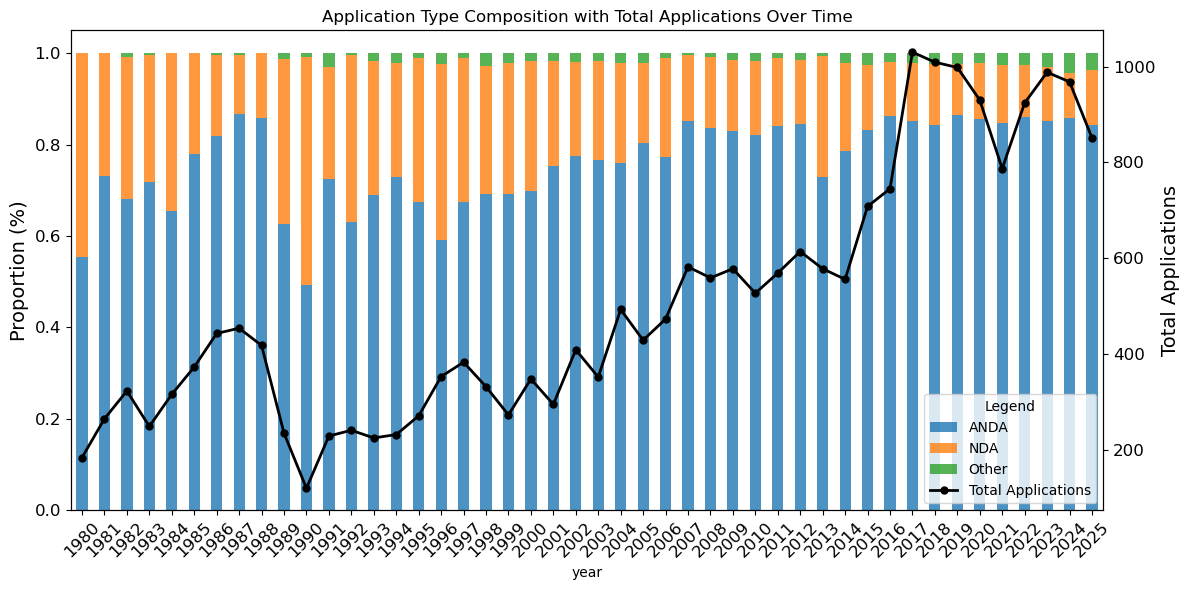

In [179]:
df = df_all.copy()
year_filter = 1980
# --- Filter to 1980+ ---
df = df[df["year"] >= year_filter].copy()

# classify NDA / ANDA / Other
# classify NDA / ANDA / Other
df["app_type"] = (
    df["application_number"]
      .str.extract(r"^(NDA|ANDA)", expand=False)
      .fillna("Other")
)

# compute totals and proportions
counts = df.groupby(["year", "app_type"], as_index=False).size()
totals_by_year = counts.groupby("year")["size"].sum().sort_index()
counts["proportion"] = counts["size"] / counts.groupby("year")["size"].transform("sum")

pivot = counts.pivot(index="year", columns="app_type", values="proportion").fillna(0)
pivot = pivot.sort_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# stacked bars
bar_plot = pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    alpha=0.8
)

# x positions of bars
x_positions = np.arange(len(pivot.index))

# total applications line
ax2 = ax1.twinx()
line_plot, = ax2.plot(
    x_positions,
    totals_by_year.values,
    marker="o",
    color="black",
    linewidth=2,
    markersize=5,
    zorder=10,
    label="Total Applications"
)

# axis labels
ax1.set_ylabel("Proportion (%)", fontsize=14)
ax2.set_ylabel("Total Applications",fontsize=14)
ax1.set_title("Application Type Composition with Total Applications Over Time")

# x-axis tick labels
ax1.set_xticks(x_positions)
ax1.set_xticklabels(pivot.index, rotation=45)

ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)

# --- MERGE LEGENDS (bars + line) ---
bar_handles, bar_labels = ax1.get_legend_handles_labels()
line_handles = [line_plot]
line_labels = ["Total Applications"]

ax1.legend(
    bar_handles + line_handles,
    bar_labels + line_labels,
    title="Legend",
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [162]:
df_all["year"] = df_all["year"].astype(int)

# Pick the years to compare
years_to_compare = [2010, 2013, 2017, 2020, 2023]

# Filter your dataset
df_compare = df_all[df_all["year"].isin(years_to_compare)].copy()

# Fill NaN submission class with something meaningful
df_compare["submission_class_code_description"] = (
    df_compare["submission_class_code_description"]
    .fillna("Unknown / Not Specified")
    .replace("", "Unknown / Not Specified")
)

# Group and count each submission class description per year
pivot = (
    df_compare
    .groupby(["submission_class_code_description", "year"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Sort by latest year or overall total
pivot = pivot.sort_values(by=years_to_compare[-1], ascending=False)

# Add total row
pivot.loc["Total"] = pivot.sum()

pivot

year,2010,2013,2017,2020,2023
submission_class_code_description,,,,,
Unknown / Not Specified,432,321,859,800,842
Type 1 - New Molecular Entity,20,25,44,53,52
Type 5 - New Formulation or New Manufacturer,20,26,43,24,35
Type 3 - New Dosage Form,29,27,28,22,27
Type 4 - New Combination,16,6,17,8,13
Not Applicable,1,101,21,5,4
Type 2 - New Active Ingredient,0,3,3,4,4
Type 1 - New Molecular Entity and Type 4 - New Combination,1,2,3,2,3
Type 10 - New Indication Submitted as Distinct NDA - Not Consolidated,0,0,1,3,3


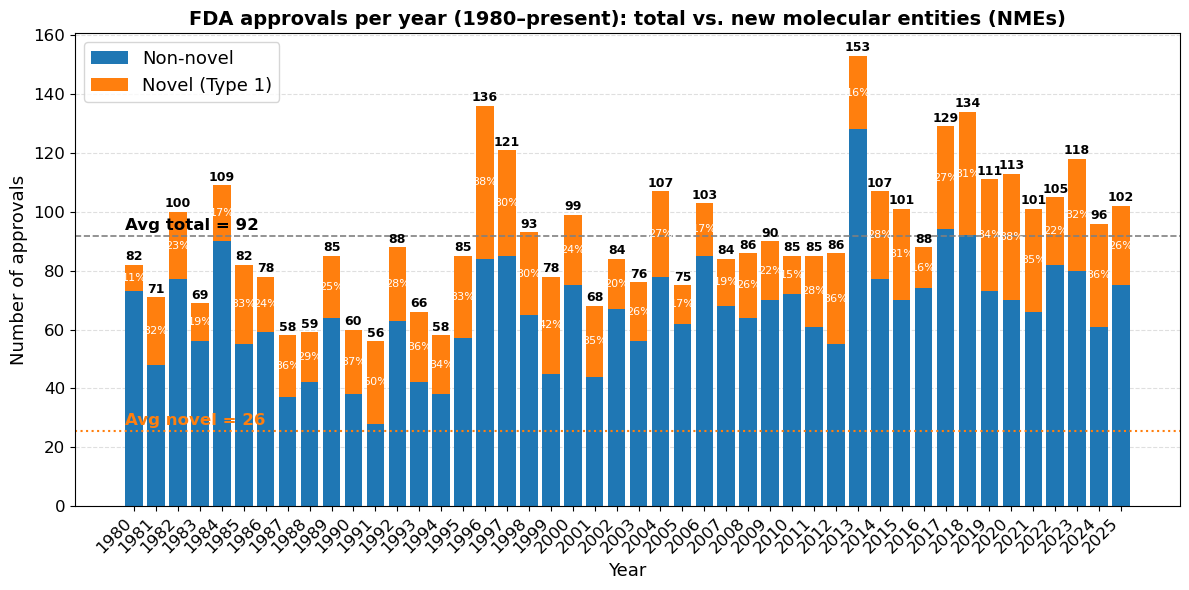

In [184]:
# --- Ensure dtypes ---
df_all["year"] = pd.to_numeric(df_all["year"], errors="coerce").astype("Int64")
df_all["is_novel_drug_therapy"] = df_all["is_novel_drug_therapy"].fillna(False).astype(bool)
df_all["is_repurposed_therapy"] = df_all["is_repurposed_therapy"].fillna(False).astype(bool)

year_filter = 1980
# --- Filter to 1980+ ---
df_1980 = df_all[df_all["year"] >= year_filter].copy()

df_1980 = df_1980[df_1980["application_number"].str.startswith("NDA", na=False)]

# --- Aggregate per year ---
yearly = (
    df_1980.groupby("year")
    .agg(total=("application_number", "size"),
         novel=("is_novel_drug_therapy", "sum"))
    .dropna(subset=["total"])
    .sort_index()
)
yearly["non_novel"] = yearly["total"] - yearly["novel"]

# --- Averages over 1980+ period ---
avg_total = yearly["total"].mean()
avg_novel = yearly["novel"].mean()

# --- Prep arrays for plotting (use positional x to avoid dtype issues) ---
years = yearly.index.astype("int64").to_numpy()
x = np.arange(len(years))
total = yearly["total"].to_numpy()
non_novel = yearly["non_novel"].to_numpy()
novel = yearly["novel"].to_numpy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bars
ax.bar(x, non_novel, label="Non-novel")
ax.bar(x, novel, bottom=non_novel, label="Novel (Type 1)")

# Total numbers on top of each bar
for xi, tot in zip(x, total):
    ax.text(xi, tot + 0.5, f"{int(tot)}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Novel proportion (%) inside the novel segment
for xi, base, nv, tot in zip(x, non_novel, novel, total):
    if nv > 0 and tot > 0:
        prop = nv / tot
        ax.text(xi, base + nv/2, f"{prop:.0%}", ha="center", va="center", fontsize=8, color="white")

# Average lines (single y-axis)
ax.axhline(avg_total, color="gray", linestyle="--", linewidth=1.2)
ax.text(-0.4, avg_total + 1, f"Avg total = {avg_total:.0f}", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(avg_novel, color="tab:orange", linestyle=":", linewidth=1.5)
ax.text(-0.4, avg_novel + 1, f"Avg novel = {avg_novel:.0f}", va="bottom", color="tab:orange", fontsize=12, fontweight="bold")

# Labels & style
ax.set_title(f"FDA approvals per year ({str(year_filter)}–present): total vs. new molecular entities (NMEs)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of approvals", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right")
ax.tick_params(axis="both", labelsize=12)


ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, fontsize=13)

plt.tight_layout()
plt.show()


In [185]:
# Starting from your original df, e.g. df_orig
df = df_all.copy()
print(df.shape)
df = df[df["application_number"].str.startswith("NDA", na=False)]
print(df.shape)

df["submission_class_code_description"] = (
    df["submission_class_code_description"]
    .fillna("Unknown / Not Specified")
    .replace("", "Unknown / Not Specified")
)
# If one row == one NDA submission, use size():
df_counts = (
    df.groupby(["year", "submission_class_code_description"])
      .size()
      .reset_index(name="count")
)
df_counts

(25712, 7)
(5387, 7)


,year,submission_class_code_description,count
0,1939,Unknown / Not Specified,7
1,1940,Type 4 - New Combination,1
2,1940,Type 5 - New Formulation or New Manufacturer,1
3,1940,Unknown / Not Specified,1
4,1941,Type 5 - New Formulation or New Manufacturer,1
...,...,...,...
611,2025,Type 3 - New Dosage Form and Type 4 - New Comb...,1
612,2025,Type 4 - New Combination,4
613,2025,Type 5 - New Formulation or New Manufacturer,25
614,2025,Type 7 - Drug Already Marketed without Approve...,1


In [186]:
df_counts.submission_class_code_description.unique()


array(['Unknown / Not Specified', 'Type 4 - New Combination',
       'Type 5 - New Formulation or New Manufacturer',
       'Type 1 - New Molecular Entity', 'Type 3 - New Dosage Form',
       'Type 2 - New Active Ingredient',
       'Type 1 - New Molecular Entity and Type 4 - New Combination',
       'Type 2 New Active Ingredient and Type 4 New Combination',
       'Type 6 - New Indication (no longer used)',
       'Type 2 - New Active Ingredient and Type 3 - New Dosage Form',
       'Type 3 - New Dosage Form and Type 4 - New Combination',
       'Type 8 - Partial Rx to OTC Switch',
       'Type 7 - Drug Already Marketed without Approved NDA',
       'Type 9 - New Indication Submitted as Distinct NDA, Consolidated with Original NDA after Approval',
       'Efficacy', 'Medical Gas',
       'Type 10 - New Indication Submitted as Distinct NDA - Not Consolidated',
       'New Combination and New Formulation or New Manufacturer'],
      dtype=object)

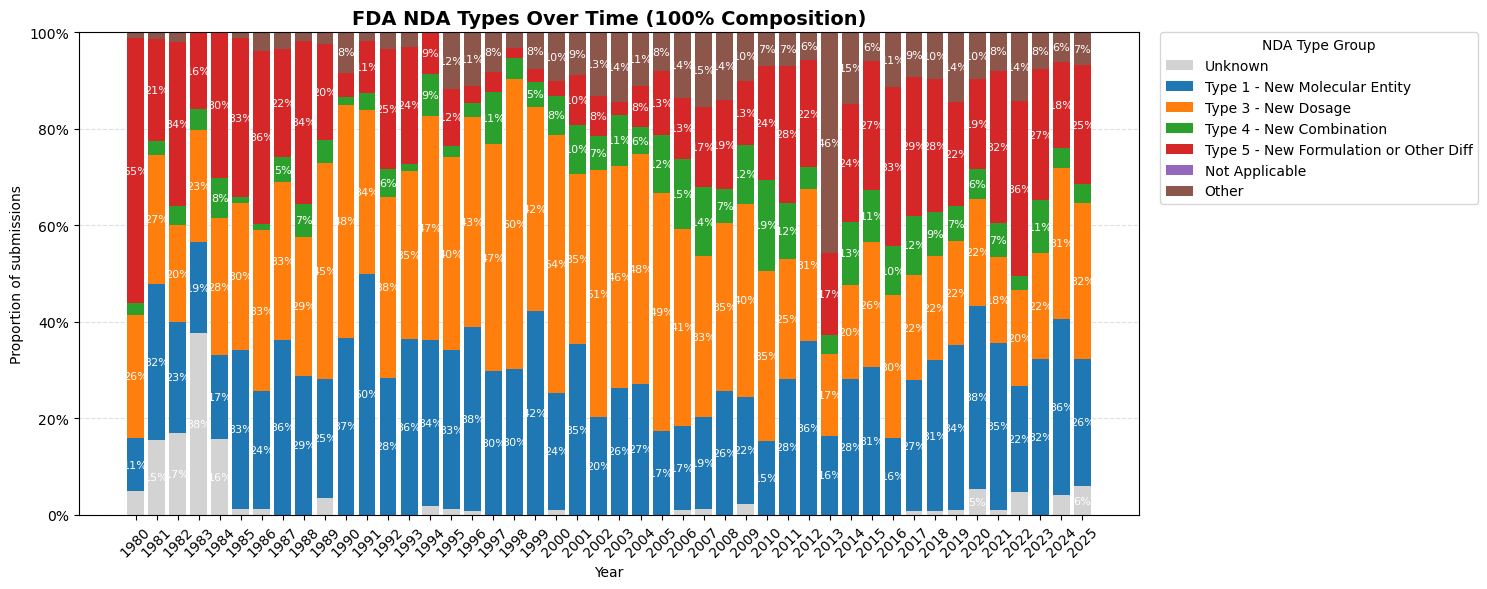

In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = df_counts.copy()
year_filter = 1980

# --- Filter by year ---
df = df[df["year"] >= year_filter].copy()

# --- 1. Map raw class strings into groups ---

def collapse_type(cat: str) -> str:
    if cat == "Type 1 - New Molecular Entity":
        return "Type 1 - New Molecular Entity"
    if cat == "Type 1 - New Molecular Entity and Type 4 - New Combination":
        # count these as Type 1 as well
        return "Type 1 - New Molecular Entity"

    if cat.startswith("Type 3"):
        return "Type 3 - New Dosage"

    if cat.startswith("Type 4") and "Type 3" not in cat:
        return "Type 4 - New Combination"

    if cat.startswith("Type 5"):
        return "Type 5 - New Formulation or Other Diff"

    if cat.startswith("Unknown / Not Specified"):
        return "Unknown"

    if cat.startswith("Not Applicable"):
        return "Not Applicable"

    return "Other"

df["class_group"] = df["submission_class_code_description"].apply(collapse_type)

# --- 2. Aggregate counts per year per group ---

yearly = (
    df.groupby(["year", "class_group"])["count"]
      .sum()
      .reset_index()
)

# Pivot into matrix for stacked bars
pivot = yearly.pivot(index="year", columns="class_group", values="count").fillna(0)

# --- 3. Ensure consistent category order ---
# Put Unknown FIRST so it's the background / bottom of the stack
cols_order = [
    "Unknown",
    "Type 1 - New Molecular Entity",
    "Type 3 - New Dosage",
    "Type 4 - New Combination",
    "Type 5 - New Formulation or Other Diff",
    "Not Applicable",
    "Other",
]

for col in cols_order:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[cols_order]

# --- 4. Convert counts → proportions (100% stacked bar) ---

prop = pivot.div(pivot.sum(axis=1), axis=0)

# --- 5. Plot ---

years = prop.index.astype(int).to_numpy()
x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(15, 6))

bottom = np.zeros(len(years))

for col in cols_order:
    values = prop[col].to_numpy()
    if col == "Unknown":
        # gray background segment
        ax.bar(x, values, bottom=bottom, label=col, color="lightgray")
    else:
        ax.bar(x, values, bottom=bottom, label=col)
    bottom += values

# --- 6. Add percentage labels inside bars ---
for i, year in enumerate(years):
    cum = 0
    for col in cols_order:
        val = prop.loc[year, col]
        if val > 0.05:  # threshold for visibility
            ax.text(
                i, cum + val/2, f"{val:.0%}",
                ha="center", va="center",
                fontsize=8, color="white"
            )
        cum += val

# --- 7. Style ---

ax.set_title("FDA NDA Types Over Time (100% Composition)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of submissions")
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)

ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{int(v*100)}%" for v in np.linspace(0, 1, 6)])

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Legend ordered like bars (already in cols_order) and placed outside
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    title="NDA Type Group",
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.
)

plt.tight_layout()
plt.show()


## Merge with DS drugs

In [22]:
terms_path = "out/unique_drug_terms_218510.csv"
terms = pd.read_csv(terms_path)
terms_for_details = terms[terms['n_articles']>1]
terms_for_details = terms_for_details[terms_for_details["drug_term_umls_norm_manual_clean"].str.len() > 2]

terms_for_details

,drug_term_umls_norm_manual_clean,n_articles
0,Dexamethasone,5865
1,Acetylcysteine,4463
2,Doxorubicin,4411
3,NG-Nitroarginine Methyl Ester,4166
4,Sirolimus,3839
...,...,...
58680,AGN 194310,2
58681,67cu -,2
58682,verapamil and diltiazem,2
58683,AGN 204396,2


In [23]:
df_orig.shape

(25712, 22)

In [24]:
df_orig = df_orig[
    ~(df_orig["brand_name"].isna() | (df_orig["brand_name"].astype(str).str.strip() == "") |
      df_orig["active_ingredients"].isna() | (df_orig["active_ingredients"].astype(str).str.strip() == ""))
]
df_orig.shape

(25361, 22)

In [25]:
df_orig.columns

Index(['application_number', 'sponsor_name', 'submission_type',
       'submission_status_date', 'submission_class_code_description', 'year',
       'brand_name', 'dosage_form', 'route', 'marketing_status',
       'active_ingredients', 'openfda_brand_name', 'openfda_generic_name',
       'openfda_route', 'openfda_substance_name', 'label_brand_name',
       'label_generic_name', 'label_manufacturer_name', 'label_substance_name',
       'indications_first_sent', 'indications_and_usage', 'clinical_studies'],
      dtype='object')

In [26]:
# Step 1: Make sure the column is a proper list
df_orig["active_ingredients_split"] = (
    df_orig["active_ingredients"]
    .astype(str)  # ensure string
    .str.split(r",\s*")  # split on comma + optional spaces
)

# Step 2: Explode into separate rows
df_orig = df_orig.explode("active_ingredients_split", ignore_index=True)
df_orig.shape

(29788, 23)

In [27]:
df_orig.head()

,application_number,sponsor_name,submission_type,submission_status_date,submission_class_code_description,year,brand_name,dosage_form,route,marketing_status,...,openfda_route,openfda_substance_name,label_brand_name,label_generic_name,label_manufacturer_name,label_substance_name,indications_first_sent,indications_and_usage,clinical_studies,active_ingredients_split
0,ANDA076194,WATSON LABS,ORIG,20020701,NaN,2002,LISINOPRIL AND HYDROCHLOROTHIAZIDE,TABLET,ORAL,Prescription,...,ORAL,"HYDROCHLOROTHIAZIDE, LISINOPRIL",Lisinopril and Hydrochlorothiazide,LISINOPRIL AND HYDROCHLOROTHIAZIDE,"Actavis Pharma, Inc.","HYDROCHLOROTHIAZIDE, LISINOPRIL",INDICATIONS AND USAGE Lisinopril and Hydrochlo...,INDICATIONS AND USAGE Lisinopril and Hydrochlo...,[],HYDROCHLOROTHIAZIDE
1,ANDA076194,WATSON LABS,ORIG,20020701,NaN,2002,LISINOPRIL AND HYDROCHLOROTHIAZIDE,TABLET,ORAL,Prescription,...,ORAL,"HYDROCHLOROTHIAZIDE, LISINOPRIL",Lisinopril and Hydrochlorothiazide,LISINOPRIL AND HYDROCHLOROTHIAZIDE,"Actavis Pharma, Inc.","HYDROCHLOROTHIAZIDE, LISINOPRIL",INDICATIONS AND USAGE Lisinopril and Hydrochlo...,INDICATIONS AND USAGE Lisinopril and Hydrochlo...,[],LISINOPRIL
2,ANDA076206,ROCKWELL MEDCL,ORIG,20030917,NaN,2003,CALCITRIOL,INJECTABLE,INJECTION,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CALCITRIOL
3,ANDA076212,APOTEX,ORIG,20040616,NaN,2004,CARBIDOPA AND LEVODOPA,"TABLET, EXTENDED RELEASE",ORAL,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARBIDOPA
4,ANDA076212,APOTEX,ORIG,20040616,NaN,2004,CARBIDOPA AND LEVODOPA,"TABLET, EXTENDED RELEASE",ORAL,Discontinued,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LEVODOPA


In [28]:
df_orig_info = df_orig[['sponsor_name','year','application_number', 'brand_name', 'active_ingredients_split', 'clinical_studies', 'indications_first_sent', 'indications_and_usage']]

In [29]:
df_orig_info

,sponsor_name,year,application_number,brand_name,active_ingredients_split,clinical_studies,indications_first_sent,indications_and_usage
0,WATSON LABS,2002,ANDA076194,LISINOPRIL AND HYDROCHLOROTHIAZIDE,HYDROCHLOROTHIAZIDE,[],INDICATIONS AND USAGE Lisinopril and Hydrochlo...,INDICATIONS AND USAGE Lisinopril and Hydrochlo...
1,WATSON LABS,2002,ANDA076194,LISINOPRIL AND HYDROCHLOROTHIAZIDE,LISINOPRIL,[],INDICATIONS AND USAGE Lisinopril and Hydrochlo...,INDICATIONS AND USAGE Lisinopril and Hydrochlo...
2,ROCKWELL MEDCL,2003,ANDA076206,CALCITRIOL,CALCITRIOL,NaN,NaN,NaN
3,APOTEX,2004,ANDA076212,CARBIDOPA AND LEVODOPA,CARBIDOPA,NaN,NaN,NaN
4,APOTEX,2004,ANDA076212,CARBIDOPA AND LEVODOPA,LEVODOPA,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
29783,MYLAN,2003,ANDA076154,LORATADINE,LORATADINE,[],Uses temporarily relieves these symptoms due t...,Uses temporarily relieves these symptoms due t...
29784,APOTEX INC,2003,ANDA076155,IPRATROPIUM BROMIDE,IPRATROPIUM BROMIDE,[],INDICATIONS AND USAGE Ipratropium bromide nasa...,INDICATIONS AND USAGE Ipratropium bromide nasa...
29785,WATSON LABS TEVA,2004,ANDA076162,CARBOPLATIN,CARBOPLATIN,NaN,NaN,NaN
29786,DR REDDYS,2003,ANDA076163,AMIODARONE HYDROCHLORIDE,AMIODARONE HYDROCHLORIDE,NaN,NaN,NaN


In [30]:
# 1) Build normalized join keys (upper + strip)
df_counts = terms_for_details.copy()
df_exploded = df_orig_info.copy()

df_counts["__key"] = df_counts["drug_term_umls_norm_manual_clean"].astype(str).str.upper().str.strip()
df_exploded["__key"] = df_exploded["active_ingredients_split"].astype(str).str.upper().str.strip()

# 2) Left-merge ON the ingredient (keep all rows from df_exploded)
df_merged = df_counts.merge(
    df_exploded,
    on="__key",
    how="left"
)

# 3) Clean up
df_merged = df_merged.drop(columns="__key")
df_merged

,drug_term_umls_norm_manual_clean,n_articles,sponsor_name,year,application_number,brand_name,active_ingredients_split,clinical_studies,indications_first_sent,indications_and_usage
0,Dexamethasone,5865,SUN PHARM INDUSTRIES,1974.0,ANDA084013,DEXAMETHASONE,DEXAMETHASONE,NaN,NaN,NaN
1,Dexamethasone,5865,WHITEWORTH TOWN PLSN,1975.0,ANDA084327,DEXAMETHASONE,DEXAMETHASONE,NaN,NaN,NaN
2,Dexamethasone,5865,WATSON LABS,1977.0,ANDA085455,DEXAMETHASONE,DEXAMETHASONE,NaN,NaN,NaN
3,Dexamethasone,5865,HIKMA,1983.0,ANDA088248,DEXAMETHASONE,DEXAMETHASONE,[],INDICATIONS AND USAGE Allergic States Control ...,INDICATIONS AND USAGE Allergic States Control ...
4,Dexamethasone,5865,EYEPOINT PHARMS,2018.0,NDA208912,DEXYCU KIT,DEXAMETHASONE,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
73601,AGN 194310,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73602,67cu -,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73603,verapamil and diltiazem,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73604,AGN 204396,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
df_ds_drugs_with_FDA_info = df_merged[df_merged["application_number"].notna()]
df_ds_drugs_with_FDA_info

,drug_term_umls_norm_manual_clean,n_articles,sponsor_name,year,application_number,brand_name,active_ingredients_split,clinical_studies,indications_first_sent,indications_and_usage
0,Dexamethasone,5865,SUN PHARM INDUSTRIES,1974.0,ANDA084013,DEXAMETHASONE,DEXAMETHASONE,NaN,NaN,NaN
1,Dexamethasone,5865,WHITEWORTH TOWN PLSN,1975.0,ANDA084327,DEXAMETHASONE,DEXAMETHASONE,NaN,NaN,NaN
2,Dexamethasone,5865,WATSON LABS,1977.0,ANDA085455,DEXAMETHASONE,DEXAMETHASONE,NaN,NaN,NaN
3,Dexamethasone,5865,HIKMA,1983.0,ANDA088248,DEXAMETHASONE,DEXAMETHASONE,[],INDICATIONS AND USAGE Allergic States Control ...,INDICATIONS AND USAGE Allergic States Control ...
4,Dexamethasone,5865,EYEPOINT PHARMS,2018.0,NDA208912,DEXYCU KIT,DEXAMETHASONE,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
73099,URIDINE TRIACETATE,2,BTG INTL,2015.0,NDA208169,XURIDEN,URIDINE TRIACETATE,[],1 INDICATIONS AND USAGE XURIDEN ® is indicated...,1 INDICATIONS AND USAGE XURIDEN ® is indicated...
73129,Umeclidinium bromide,2,GLAXOSMITHKLINE,2013.0,NDA203975,ANORO ELLIPTA,UMECLIDINIUM BROMIDE,"['NCT01313650', 'NCT01313637', 'NCT02164513']",1 INDICATIONS AND USAGE Umeclidinium and Vilan...,1 INDICATIONS AND USAGE Umeclidinium and Vilan...
73130,Umeclidinium bromide,2,GLAXOSMITHKLINE,2017.0,NDA209482,TRELEGY ELLIPTA,UMECLIDINIUM BROMIDE,"['NCT01957163', 'NCT02119286', 'NCT02164513', ...",1 INDICATIONS AND USAGE TRELEGY ELLIPTA is a c...,1 INDICATIONS AND USAGE TRELEGY ELLIPTA is a c...
73131,Umeclidinium bromide,2,GLAXO GRP ENGLAND,2014.0,NDA205382,INCRUSE ELLIPTA,UMECLIDINIUM BROMIDE,"['NCT01313650', 'NCT01387230', 'NCT01957163', ...",1 INDICATIONS AND USAGE INCRUSE ELLIPTA is ind...,1 INDICATIONS AND USAGE INCRUSE ELLIPTA is ind...


In [38]:
df_with_indications = df_ds_drugs_with_FDA_info[df_ds_drugs_with_FDA_info["indications_first_sent"].notna()]
df_with_indications['unique_id'] = (
    df_with_indications['drug_term_umls_norm_manual_clean']
    .str.replace(" ", "_")
    .str.lower()
    +"_" + df_with_indications['application_number'].astype(str)
)
df_with_indications.to_csv("out/drugs_with_indications.csv", index=False)

/sctmp/sdonev/ipykernel_2306867/2408460511.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_indications['unique_id'] = (


In [33]:
df_ds_drugs_with_FDA_info.drug_term_umls_norm_manual_clean.nunique()

1256

In [34]:
df_filtered = df_ds_drugs_with_FDA_info[
    (df_ds_drugs_with_FDA_info["active_ingredients_split"] == "DEXAMETHASONE") &
    (df_ds_drugs_with_FDA_info["application_number"].astype(str).str.startswith("NDA"))
]
df_filtered

,drug_term_umls_norm_manual_clean,n_articles,sponsor_name,year,application_number,brand_name,active_ingredients_split,clinical_studies,indications_first_sent,indications_and_usage
4,Dexamethasone,5865,EYEPOINT PHARMS,2018.0,NDA208912,DEXYCU KIT,DEXAMETHASONE,NaN,NaN,NaN
5,Dexamethasone,5865,SANDOZ,1988.0,NDA050592,TOBRADEX,DEXAMETHASONE,[],INDICATIONS AND USAGE Tobramycin and dexametha...,INDICATIONS AND USAGE Tobramycin and dexametha...
19,Dexamethasone,5865,ABBVIE,2009.0,NDA022315,OZURDEX,DEXAMETHASONE,[],1 INDICATIONS AND USAGE OZURDEX ® is a cortico...,1 INDICATIONS AND USAGE OZURDEX ® is a cortico...
20,Dexamethasone,5865,ASPEN GLOBAL INC,1960.0,NDA012674,HEXADROL,DEXAMETHASONE,NaN,NaN,NaN
21,Dexamethasone,5865,ASPEN GLOBAL INC,1962.0,NDA012675,HEXADROL,DEXAMETHASONE,NaN,NaN,NaN
22,Dexamethasone,5865,OCULAR THERAPEUTIX,2018.0,NDA208742,DEXTENZA,DEXAMETHASONE,"['NCT02034019', 'NCT02089113', 'NCT02736175', ...",1 INDICATIONS AND USAGE DEXTENZA ® is a cortic...,1 INDICATIONS AND USAGE DEXTENZA ® is a cortic...
23,Dexamethasone,5865,HARROW EYE,2009.0,NDA050818,TOBRADEX ST,DEXAMETHASONE,[],1 INDICATIONS AND USAGE TOBRADEX ST ophthalmic...,1 INDICATIONS AND USAGE TOBRADEX ST ophthalmic...
36,Dexamethasone,5865,HARROW EYE,1963.0,NDA050023,MAXITROL,DEXAMETHASONE,[],INDICATIONS AND USAGE For steroid-responsive i...,INDICATIONS AND USAGE For steroid-responsive i...
37,Dexamethasone,5865,NOVARTIS,1988.0,NDA050616,TOBRADEX,DEXAMETHASONE,[],INDICATIONS AND USAGE: TOBRADEX (tobramycin an...,INDICATIONS AND USAGE: TOBRADEX (tobramycin an...
40,Dexamethasone,5865,DEXCEL,2019.0,NDA211379,HEMADY,DEXAMETHASONE,[],1 INDICATIONS AND USAGE HEMADY is indicated in...,1 INDICATIONS AND USAGE HEMADY is indicated in...


In [35]:
df_ds_drugs_with_FDA_info[df_ds_drugs_with_FDA_info['active_ingredients_split']=="RITUXIMAB"].indications_first_sent.iloc[0]

"1 INDICATIONS AND USAGE RITUXAN is a CD20-directed cytolytic antibody indicated for the treatment of: Adult patients with Non-Hodgkin's Lymphoma (NHL) ( 1.1 )"

In [36]:
df_ds_drugs_with_FDA_info[df_ds_drugs_with_FDA_info['active_ingredients_split']=="RITUXIMAB"].indications_first_sent.iloc[1]

'1 INDICATIONS AND USAGE RITUXAN HYCELA is a combination of rituximab, a CD20-directed cytolytic antibody, and hyaluronidase human, an endoglycosidase, indicated for the treatment of adult patients with: Follicular Lymphoma (FL) ( 1.1 ) Relapsed or refractory, follicular lymphoma as a single agent Previously untreated follicular lymphoma in combination with first line chemotherapy and, in patients achieving a complete or partial response to rituximab in combination with chemotherapy, as single-agent maintenance therapy Non-progressing (including stable disease), follicular lymphoma as a single agent after first-line cyclophosphamide, vincristine, and prednisone (CVP) chemotherapy Diffuse Large B-cell Lymphoma (DLBCL) ( 1.2 ) Previously untreated diffuse large B-cell lymphoma in combination with cyclophosphamide, doxorubicin, vincristine, prednisone (CHOP) or other anthracycline-based chemotherapy regimens Chronic Lymphocytic Leukemia (CLL) ( 1.3 ) Previously untreated and previously tr

## Process LLM Drug Indications

In [188]:
llm_indications = pd.read_csv("./drugs_with_indications_LLM_cleaned.csv")

In [190]:
llm_indications_data = llm_indications[['unique_id', 'drug_term_umls_norm_manual_clean', 'year','application_number', 'active_ingredients_split', 'disease_from_indications']]

In [191]:
llm_indications_data

,unique_id,drug_term_umls_norm_manual_clean,year,application_number,active_ingredients_split,disease_from_indications
0,dexamethasone_ANDA088248,Dexamethasone,1983.0,ANDA088248,DEXAMETHASONE,asthma|atopic dermatitis|contact dermatitis|dr...
1,dexamethasone_NDA050592,Dexamethasone,1988.0,NDA050592,DEXAMETHASONE,steroid-responsive inflammatory ocular conditi...
2,dexamethasone_ANDA062938,Dexamethasone,1989.0,ANDA062938,DEXAMETHASONE,steroid-responsive inflammatory ocular conditi...
3,dexamethasone_ANDA064135,Dexamethasone,1995.0,ANDA064135,DEXAMETHASONE,steroid-responsive inflammatory ocular conditi...
4,dexamethasone_ANDA080399,Dexamethasone,1971.0,ANDA080399,DEXAMETHASONE,asthma|atopic dermatitis|contact dermatitis|dr...
...,...,...,...,...,...,...
8047,uridine_triacetate_NDA208159,URIDINE TRIACETATE,2015.0,NDA208159,URIDINE TRIACETATE,cardiac toxicity|central nervous system toxici...
8048,uridine_triacetate_NDA208169,URIDINE TRIACETATE,2015.0,NDA208169,URIDINE TRIACETATE,hereditary orotic aciduria
8049,umeclidinium_bromide_NDA203975,Umeclidinium bromide,2013.0,NDA203975,UMECLIDINIUM BROMIDE,chronic obstructive pulmonary disease|COPD
8050,umeclidinium_bromide_NDA209482,Umeclidinium bromide,2017.0,NDA209482,UMECLIDINIUM BROMIDE,chronic obstructive pulmonary disease|COPD


In [194]:
llm_indications_data[llm_indications_data['drug_term_umls_norm_manual_clean']=="Cladribine"]

,unique_id,drug_term_umls_norm_manual_clean,year,application_number,active_ingredients_split,disease_from_indications
5017,cladribine_NDA022561,Cladribine,2019.0,NDA022561,CLADRIBINE,relapsing forms of multiple sclerosis|relapsin...
5018,cladribine_ANDA075405,Cladribine,2000.0,ANDA075405,CLADRIBINE,Hairy Cell Leukemia|anemia|neutropenia|thrombo...
5019,cladribine_ANDA076571,Cladribine,2004.0,ANDA076571,CLADRIBINE,Hairy Cell Leukemia|anemia|neutropenia|thrombo...
5020,cladribine_ANDA210856,Cladribine,2019.0,ANDA210856,CLADRIBINE,Hairy Cell Leukemia|anemia|neutropenia|thrombo...


In [195]:
#1. Split disease list into one row per disease
df_expanded = (
    llm_indications_data.assign(disease=llm_indications_data['disease_from_indications'].str.split('|'))
      .explode('disease')
      .dropna(subset=['disease'])
)

# 2. Aggregate: earliest year + list of all associated documents
result = (
    df_expanded
    .groupby(['drug_term_umls_norm_manual_clean', 'disease'], as_index=False)
    .agg(
        earliest_year=('year', 'min'),
        documents=('application_number', lambda x: sorted(set(x)))
    )
)
result

,drug_term_umls_norm_manual_clean,disease,earliest_year,documents
0,ANAKINRA,CAPS,2001.0,[BLA103950]
1,ANAKINRA,Cryopyrin-Associated Periodic Syndromes,2001.0,[BLA103950]
2,ANAKINRA,DIRA,2001.0,[BLA103950]
3,ANAKINRA,Deficiency of Interleukin-1 Receptor Antagonist,2001.0,[BLA103950]
4,ANAKINRA,NOMID,2001.0,[BLA103950]
...,...,...,...,...
4907,zolmitriptan,migraine with aura,2013.0,"[ANDA201779, ANDA204041, ANDA207021, ANDA207867]"
4908,zolmitriptan,migraine with or without aura,2013.0,"[ANDA202560, ANDA202890, ANDA202956, ANDA20428..."
4909,zolmitriptan,migraine without aura,2013.0,"[ANDA201779, ANDA204041, ANDA207021, ANDA207867]"
4910,zuranolone,PPD,2023.0,[NDA217369]


In [206]:
result[result['drug_term_umls_norm_manual_clean'].str.contains("cladribine", case=False)]


,drug_term_umls_norm_manual_clean,disease,earliest_year,documents
873,Cladribine,Hairy Cell Leukemia,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"
874,Cladribine,active secondary progressive disease,2019.0,[NDA022561]
875,Cladribine,anemia,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"
876,Cladribine,disease-related symptoms,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"
877,Cladribine,neutropenia,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"
878,Cladribine,relapsing forms of multiple sclerosis,2019.0,[NDA022561]
879,Cladribine,relapsing-remitting disease,2019.0,[NDA022561]
880,Cladribine,thrombocytopenia,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"


In [205]:
result[result['disease'].str.contains("schizophrenia", case=False)]


,drug_term_umls_norm_manual_clean,disease,earliest_year,documents
13,ARIPiprazole,Schizophrenia,2002.0,"[ANDA201519, ANDA202101, ANDA202547, ANDA20302..."
22,ARIPiprazole,schizophrenia,2013.0,"[ANDA202102, NDA202971, NDA207202, NDA216655, ..."
274,Asenapine,schizophrenia,2019.0,[NDA212268]
492,Brexpiprazole,schizophrenia,2015.0,"[ANDA213562, NDA205422]"
941,Clozapine,schizophrenia,1989.0,"[ANDA090308, ANDA201824, ANDA202873, ANDA21292..."
942,Clozapine,treatment-resistant schizophrenia,1999.0,"[ANDA075417, ANDA075713, ANDA206433]"
1686,Fluphenazine decanoate,chronic schizophrenia,1996.0,[ANDA074531]
1687,Fluphenazine decanoate,schizophrenia,1987.0,"[ANDA071413, ANDA075918, ANDA203732, ANDA20773..."
2022,Iloperidone,schizophrenia,2009.0,"[ANDA207231, NDA022192]"
2678,OLANZapine,Schizophrenia,2021.0,[NDA213378]


## FDA Website NMA data

In [211]:
all_years_df = pd.read_csv("out/NME_drugs_with_indications_LLM_cleaned_manual_val.csv")
all_years_df["is_neuro"] = all_years_df["Neuro-related (True/False)"].str.lower().str.contains("true")

all_years_df.head()

,no,drug_name,active_ingredient,approval_date,fda_use_on_approval,drug_url,year,indications_first_sent,indications_and_usage,disease_from_indications,Disease / Condition,Neuro-related (True/False),is_neuro
0,45.0,Zurampic,lesinurad,12/22/15 0:00,To treat high blood uric acid levels associate...,https://web.archive.org/web/20240428045412/htt...,2015,To treat high blood uric acid levels associate...,To treat high blood uric acid levels associate...,hyperuricemia|gout|acute arthritis of gout|uri...,hyperuricemia / gout / acute arthritis of gout...,FALSE,False
1,44.0,Uptravi,selexipag,12/21/15 0:00,To treat pulmonary arterial hypertension Drug ...,https://web.archive.org/web/20240428045412/htt...,2015,To treat pulmonary arterial hypertension Drug ...,To treat pulmonary arterial hypertension Drug ...,pulmonary arterial hypertension,pulmonary arterial hypertension,FALSE,False
2,43.0,Bridion,sugammadex,12/15/15 0:00,To reverse effects of neuromuscular blocking d...,https://web.archive.org/web/20240428045412/htt...,2015,To reverse effects of neuromuscular blocking d...,To reverse effects of neuromuscular blocking d...,neuromuscular blockade,neuromuscular blockade,TRUE,True
3,42.0,Alecensa,alectinib,12/11/15 0:00,To treat ALK-positive lung cancer Drug Trials ...,https://web.archive.org/web/20240428045412/htt...,2015,To treat ALK-positive lung cancer Drug Trials ...,To treat ALK-positive lung cancer Drug Trials ...,ALK-positive lung cancer,ALK-positive lung cancer,FALSE,False
4,41.0,Kanuma,sebelipase alfa,12/8/15 0:00,To treat patients with a rare disease known as...,https://web.archive.org/web/20240428045412/htt...,2015,To treat patients with a rare disease known as...,To treat patients with a rare disease known as...,lysosomal acid lipase deficiency,lysosomal acid lipase deficiency,FALSE,False


In [235]:
total_rows = len(all_years_df)
num_neuro = all_years_df["is_neuro"].sum()
num_non_neuro = total_rows - num_neuro
prop_neuro = num_neuro / total_rows

print("------ Neuro Approval Statistics ------")
print(f"Total drug approvals in dataset: {total_rows}")
print(f"Neuro-related approvals:         {num_neuro}")
print(f"Non-neuro approvals:             {num_non_neuro}")
print(f"Proportion neuro-related:        {prop_neuro:.3f} ({prop_neuro*100:.1f}%)")


------ Neuro Approval Statistics ------
Total drug approvals in dataset: 602
Neuro-related approvals:         115
Non-neuro approvals:             487
Proportion neuro-related:        0.191 (19.1%)


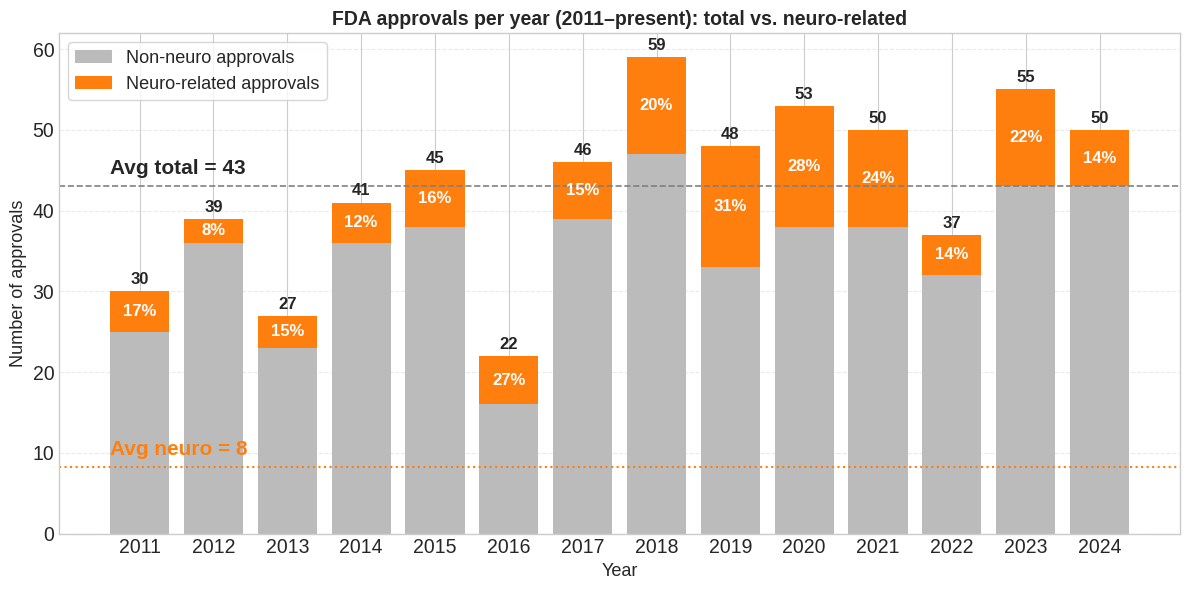

In [229]:
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure dtypes & clean ---
all_years_df["year"] = pd.to_numeric(all_years_df["year"], errors="coerce").astype("Int64")
all_years_df["is_neuro"] = all_years_df["is_neuro"].fillna(False).astype(bool)

df_neuro = all_years_df.copy()

# Drop rows with missing year
df_neuro = df_neuro.dropna(subset=["year"])
min_year = df_neuro['year'].min()
# --- Aggregate per year ---
yearly = (
    df_neuro.groupby("year")
    .agg(
        total=("is_neuro", "size"),
        neuro=("is_neuro", "sum")
    )
    .dropna(subset=["total"])
    .sort_index()
)

yearly["non_neuro"] = yearly["total"] - yearly["neuro"]

# --- Averages over the period (optional) ---
avg_total = yearly["total"].mean()
avg_neuro = yearly["neuro"].mean()

# --- Prep arrays for plotting ---
years = yearly.index.astype("int64").to_numpy()
x = np.arange(len(years))
total = yearly["total"].to_numpy()
non_neuro = yearly["non_neuro"].to_numpy()
neuro = yearly["neuro"].to_numpy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bars: non-neuro at bottom, neuro on top
ax.bar(x, non_neuro, label="Non-neuro approvals", color="#BBBBBB")
ax.bar(x, neuro, bottom=non_neuro, label="Neuro-related approvals", color="tab:orange") #"#4682B4"

# Total numbers on top of each bar
for xi, tot in zip(x, total):
    ax.text(
        xi, tot + 0.5,
        f"{int(tot)}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

# Neuro proportion (%) inside the neuro segment
for xi, base, nv, tot in zip(x, non_neuro, neuro, total):
    if nv > 0 and tot > 0:
        prop = nv / tot
        ax.text(
            xi, base + nv / 2,
            f"{prop:.0%}",
            ha="center", va="center",
            fontsize=12, color="white", fontweight="bold"
        )

# Average lines (optional, like your other plot)
ax.axhline(avg_total, color="gray", linestyle="--", linewidth=1.2)
ax.text(
    -0.4, avg_total + 1,
    f"Avg total = {avg_total:.0f}",
    va="bottom", fontsize=15, fontweight="bold"
)

ax.axhline(avg_neuro, color="tab:orange", linestyle=":", linewidth=1.5)
ax.text(
    -0.4, avg_neuro + 1,
    f"Avg neuro = {avg_neuro:.0f}",
    va="bottom", color="tab:orange", fontsize=15, fontweight="bold"
)

# Labels & style
ax.set_title(
    f"FDA approvals per year ({min_year}–present): total vs. neuro-related",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of approvals", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years],)
ax.tick_params(axis="both", labelsize=14)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, fontsize=13)

plt.tight_layout()
plt.show()


In [232]:
all_years_df_neuro = all_years_df[all_years_df["is_neuro"]]

In [234]:
all_years_df_neuro = all_years_df_neuro[['drug_name','active_ingredient','year','disease_from_indications']]
all_years_df_neuro

,drug_name,active_ingredient,year,disease_from_indications
2,Bridion,sugammadex,2015,neuromuscular blockade
17,Aristada,aripiprazole lauroxil,2015,schizophrenia
20,Vraylar,cariprazine,2015,schizophrenia|bipolar disorder
24,Addyi,flibanserin,2015,"acquired, generalized hypoactive sexual desire..."
28,Rexulti,brexpiprazole,2015,schizophrenia|major depressive disorder| depre...
...,...,...,...,...
577,Plegridy,peginterferon beta-1a,2014,relapsing forms of multiple sclerosis|multiple...
578,Belsomra,suvorexant,2014,insomnia
589,Zontivity,vorapaxar,2014,stroke
598,Northera,droxidopa,2014,neurogenic orthostatic hypotension


In [237]:
approved_neuro_after_2015 = all_years_df_neuro[all_years_df_neuro['year']>=2015]

In [248]:
approved_neuro_after_2015.to_csv("out/approved_neuro_after_2015.csv", index=False)

In [250]:
approved_neuro_after_2015 = pd.read_csv("out/approved_neuro_after_2015_manual_clean.csv")
approved_neuro_after_2015

,drug_name,active_ingredient,year,disease_from_indications,disease_from_indications_clean
0,Bridion,sugammadex,2015,neuromuscular blockade,neuromuscular blockade
1,Aristada,aripiprazole lauroxil,2015,schizophrenia,schizophrenia
2,Vraylar,cariprazine,2015,schizophrenia|bipolar disorder,schizophrenia|bipolar disorder
3,Addyi,flibanserin,2015,"acquired, generalized hypoactive sexual desire...",hypoactive sexual desire disorder
4,Rexulti,brexpiprazole,2015,schizophrenia|major depressive disorder| depre...,schizophrenia|depression
...,...,...,...,...,...
93,Miplyffa,arimoclomol,2024,Niemann-Pick disease type C,Niemann-Pick disease type C
94,Voranigo,vorasidenib,2024,Grade 2 astrocytoma|oligodendroglioma,Grade 2 astrocytoma|oligodendroglioma
95,Kisunla,donanemab-azbt,2024,Alzheimer's disease,Alzheimers disease
96,Ojemda,tovorafenib,2024,relapsed or refractory pediatric low-grade gli...,glioma


In [269]:
df_exp = (
    approved_neuro_after_2015
    .assign(disease_from_indications_clean =
            approved_neuro_after_2015["disease_from_indications_clean"].str.split("|"))
    .explode("disease_from_indications_clean")
)

# clean whitespace + remove apostrophes + lowercase
df_exp["disease_from_indications_clean"] = (
    df_exp["disease_from_indications_clean"]
    .str.replace("'", "", regex=False)
    .str.strip()
    .str.lower()
)


In [270]:
# --- Stats ---
unique_drugs = df_exp["active_ingredient"].nunique()
unique_diseases = df_exp["disease_from_indications_clean"].nunique()
unique_pairs = df_exp[["active_ingredient", "disease_from_indications_clean"]].drop_duplicates().shape[0]

print("------ Stats for Neuro-Drugs since 2015 ------")
print(f"Unique active_ingredient:              {unique_drugs}")
print(f"Unique diseases:           {unique_diseases}")
print(f"Unique drug–disease pairs: {unique_pairs}")

------ Stats for Neuro-Drugs since 2015 ------
Unique active_ingredient:              98
Unique diseases:           63
Unique drug–disease pairs: 123


In [278]:
drug_column = "active_ingredient"

# clean whitespace + remove apostrophes
df_exp["disease_from_indications_clean"] = (
    df_exp["disease_from_indications_clean"]
    .str.strip()
    .str.replace("'", "", regex=False)
)

# --- Frequency of diseases ---
disease_counts = (
    df_exp["disease_from_indications_clean"]
    .value_counts()
    .reset_index()
)
disease_counts.columns = ["disease", "count"]

# --- Unique drugs (active ingredients) per disease ---
disease_unique_drugs = (
    df_exp.groupby("disease_from_indications_clean")[drug_column]
    .nunique()
    .reset_index()
    .rename(columns={
        "disease_from_indications_clean": "disease",
        drug_column: "unique_drugs"   # or "unique_active_ingredients" if you prefer
    })
)

# --- Unique drug–disease pairs (active ingredient – disease) ---
disease_unique_pairs = (
    df_exp[["disease_from_indications_clean", drug_column]]
    .drop_duplicates()
    .groupby("disease_from_indications_clean")
    .size()
    .reset_index(name="unique_pairs")
    .rename(columns={"disease_from_indications_clean": "disease"})
)

# --- Merge into one summary table ---
disease_summary = (
    disease_counts
    .merge(disease_unique_drugs, on="disease")
    .merge(disease_unique_pairs, on="disease")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# --- Build list of active ingredients per disease ---

pairs = (
    df_exp[["disease_from_indications_clean", drug_column, "year"]]
    .sort_values("year")      
    .drop_duplicates(subset=["disease_from_indications_clean", drug_column], keep="first")
    .rename(columns={
        "disease_from_indications_clean": "disease",
        drug_column: "drug",
        "year": "FDA_approval_year"
    })
)


drugs_per_disease = (
    pairs.groupby("disease")["drug"]
    .apply(lambda s: ", ".join(sorted(s.unique())))  # comma-separated list
    .reset_index(name="drugs")
)

disease_summary_with_drugs = (
    disease_summary
    .merge(drugs_per_disease, on="disease", how="left")
)

disease_summary_with_drugs.head(10)


,disease,count,unique_drugs,unique_pairs,drugs
0,migraine,9,9,9,"atogepant, eptinezumab-jjmr, erenumab-aooe, fr..."
1,duchenne muscular dystrophy,7,7,7,"casimersen, deflazacort, eteplirsen, givinosta..."
2,multiple sclerosis,6,6,6,"daclizumab, ocrelizumab, ozanimod, ponesimod, ..."
3,schizophrenia,6,6,6,"aripiprazole lauroxil, brexpiprazole, caripraz..."
4,parkinsons disease,5,5,5,"fluorodopa F 18, istradefylline, opicapone, pi..."
5,alzheimers disease,4,4,4,"aducanumab - avwa, donanemab-azbt, flortaucipi..."
6,amyloidosis,4,4,4,"eplontersen, inotersen, patisiran, vutrisiran"
7,neuroendocrine tumors,4,4,4,"Ga-68-DOTATOC, copper Cu 64 dotatate injection..."
8,seizures,4,4,4,"brivaracetam, cenobamate, ganaxolone, stiripentol"
9,depression,4,4,4,"brexanolone, brexpiprazole, gepirone, zuranolone"


In [279]:
pairs

,disease,drug,FDA_approval_year
0,neuromuscular blockade,sugammadex,2015
6,venous thromboembolism,edoxaban,2015
6,atrial fibrillation,edoxaban,2015
6,systemic embolism,edoxaban,2015
5,neuroblastoma,dinutuximab,2015
...,...,...,...
93,niemann-pick disease type c,arimoclomol,2024
94,grade 2 astrocytoma,vorasidenib,2024
94,oligodendroglioma,vorasidenib,2024
95,alzheimers disease,donanemab-azbt,2024


In [287]:
pairs.to_csv("out/FDA_neuro_drug_disease_pairs_after_2015.csv",index=False)

## linking to ontologies

In [280]:
import sys
sys.path.append("../04_normalization")   # adjust path to your real folder
from neural_based_nen import main


In [291]:
data_dir =  "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/"

In [292]:
mapping_type = "disease"
col_to_map = "disease"
input_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015.csv"
output_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease.csv"

main(mapping_type, col_to_map, data_dir, input_file, output_file, stats_dir=None)

Input file: /scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015.csv


/home/sdonev/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Starting normalization for: DISEASE with cdist 9.7
Loaded embeddings: (129189, 768), term_id_pairs: 129189


Mapping disease NER to mondo: 100%|██████████| 123/123 [00:26<00:00,  4.63it/s]

Normalization time for 'disease': 0:00:28
Output saved to: /scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease.csv


In [293]:
mapping_type = "drug"
col_to_map = "drug"
input_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease.csv"
output_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease_drug.csv"

main(mapping_type, col_to_map, data_dir, input_file, output_file, stats_dir=None)

Input file: /scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease.csv


/home/sdonev/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Starting normalization for: DRUG with cdist 7.8
Loaded embeddings: (474316, 768), term_id_pairs: 474316


Mapping drug NER to umls: 100%|██████████| 123/123 [01:21<00:00,  1.52it/s]

Normalization time for 'drug': 0:01:29
Output saved to: /scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease_drug.csv
